In [1]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import scanpy as sc
import matplotlib.pyplot as plt

from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.SpaceTravLR.dataset_configs import dataset_paths
from metab_processing.LinearRegression.least_squares import (
    fit_gene_betas, rank_coefficients, plot_top_coefficients,
    subsample_metab_betas, plot_beta_histogram)

In [2]:
data_dir = f'{DATA_DIR}/Alexi_UC_Spliced'
samples = [f'13473_HS4_UC-Slice_{i}' for i in (1, 2, 3, 4)]

ANNOT_COL = '25_06_11_ICI_5K_Coarse_annotations'
T_CELL   = 'IEC'          # <- set to the T-cell label in ANNOT_COL (see inspect cell below)
GLUCOSE  = 'D-Glucose'  # <- set to glucose's name in uns['x_metab_modulators']
HIST_GENE = 'FOXP3'        # None -> first stored gene; or set a specific target gene
N_SUB, FRAC = 200, 0.8

def load_x(dataset):
    return sc.read_h5ad(dataset_paths(dataset, data_dir=data_dir)['dataset_dir'] / 'LinearRegression' / 'x_adata.h5ad')

In [3]:
# Inspect one sample to set T_CELL / GLUCOSE above if the defaults don't match.
ad0 = load_x(samples[0])
print('annotations:', list(ad0.obs[ANNOT_COL].unique()))
print('metabolites:', [m.split('@', 1)[1] for m in ad0.uns['x_metab_modulators']])
print('genes:', ad0.uns['x_genes'])

annotations: ['Plasma', 'Fibroblast', 'Muscularis_mucosa', 'B', 'IEC', 'Myofibroblast', 'MNP', 'T', 'Pericyte', 'MAST', 'Enteric_glia', 'Endothelial']
metabolites: ['(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid|1b,3a,12a-Trihydroxy-5b-cholanoic acid|3-Sulfodeoxycholic acid|3alpha,7alpha-Dihydroxycoprostanic acid|3b-Hydroxy-5-cholenoic acid|Chenodeoxycholic acid|Chenodeoxycholic acid 3-sulfate|Coprocholic acid|Deoxycholic acid|Folinic acid|Glutathione|Glycochenodeoxycholate-3-sulfate|Hyodeoxycholic acid|Isoursodeoxycholic acid|Lithocholic acid|Sulfolithocholic acid|Trihydroxycoprostanoic acid|Ursocholic acid|Ursodeoxycholic acid|Ursodeoxycholic acid 3-sulfate|Varanic acid', "17a-Ethynylestradiol|3',4'-Dihydrodiol|4'-Hydroxydiclofenac|4-Hydroxycyclophosphamide|8-Hydroxycarvedilol|E-3179|Estriol|Glycerol|N-Desmethylcitalopram|N-Desmethyleletriptan|O-Deethylated candesartan", '2-Hydroxychlorpropamide', '25-Hydroxycholesterol', '4-ene-Valproic acid', '5-Hy

In [4]:
# T cells in the relevant sample: OLS betas ranked by |magnitude|.
betas = fit_gene_betas(ad0, annot_col=ANNOT_COL, annot_value=T_CELL, method='l1', penalty=0.00001)


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.475612e-01, tolerance: 6.720e-02
  model = cd_fast.enet_coordinate_descent(
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370337e+00, tolerance: 5.735e-02
  model = cd_fast.enet_coordinate_descent(


,gene,factor,group,beta,r2,n_cells
18316,SLC9A3,metab@Anion exchange,metab,9.962738,0.987120,7778
17267,SLC9A3,PRDM1,tf,8.090892,0.987120,7778
30030,NDRG1,metab@Water,metab,6.402733,0.986061,7778
17293,SLC9A3,TWIST2,tf,-3.381819,0.987120,7778
31155,ATP1A1,ATF3,tf,-3.198800,0.953390,7778
17303,SLC9A3,ZNF449,tf,2.921847,0.987120,7778
31235,ATP1A1,POU2F2,tf,-2.483548,0.953390,7778
31180,ATP1A1,FLI1,tf,-2.445126,0.953390,7778
17253,SLC9A3,MEF2A,tf,2.225891,0.987120,7778
28855,NDRG1,PRDM1,tf,2.087932,0.986061,7778


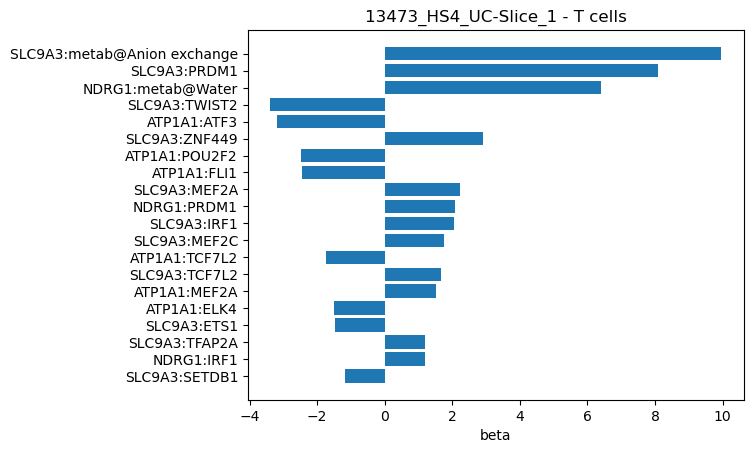

In [7]:
display(rank_coefficients(betas).head(60))
plot_top_coefficients(betas, top=20).set_title(f'{samples[0]} - T cells');

(array([[5730.,    0.,    0., ...,    0.,    0.,    0.],
        [5730.,    0.,    0., ...,    0.,    0.,    0.],
        [5730.,    0.,    0., ...,    0.,    0.,    0.],
        ...,
        [5730.,    0.,    0., ...,    0.,    0.,    0.],
        [5730.,    0.,    0., ...,    0.,    0.,    0.],
        [5730.,    0.,    0., ...,    0.,    0.,    0.]], shape=(2582, 10)),
 array([0.        , 0.13862944, 0.27725887, 0.41588831, 0.55451775,
        0.69314718, 0.83177662, 0.97040606, 1.10903549, 1.24766493,
        1.38629436]),
 <a list of 2582 BarContainer objects>)

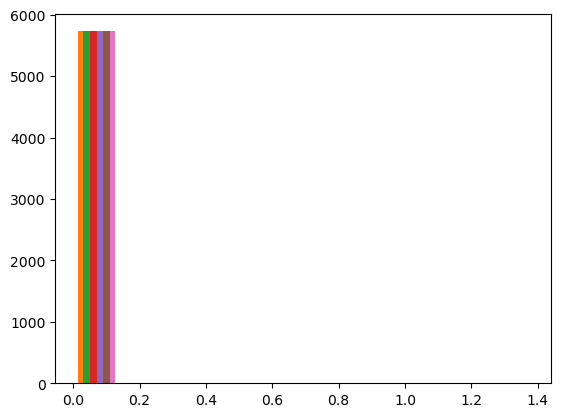

In [12]:
plt.hist(ad0.obsm['x_factors'])

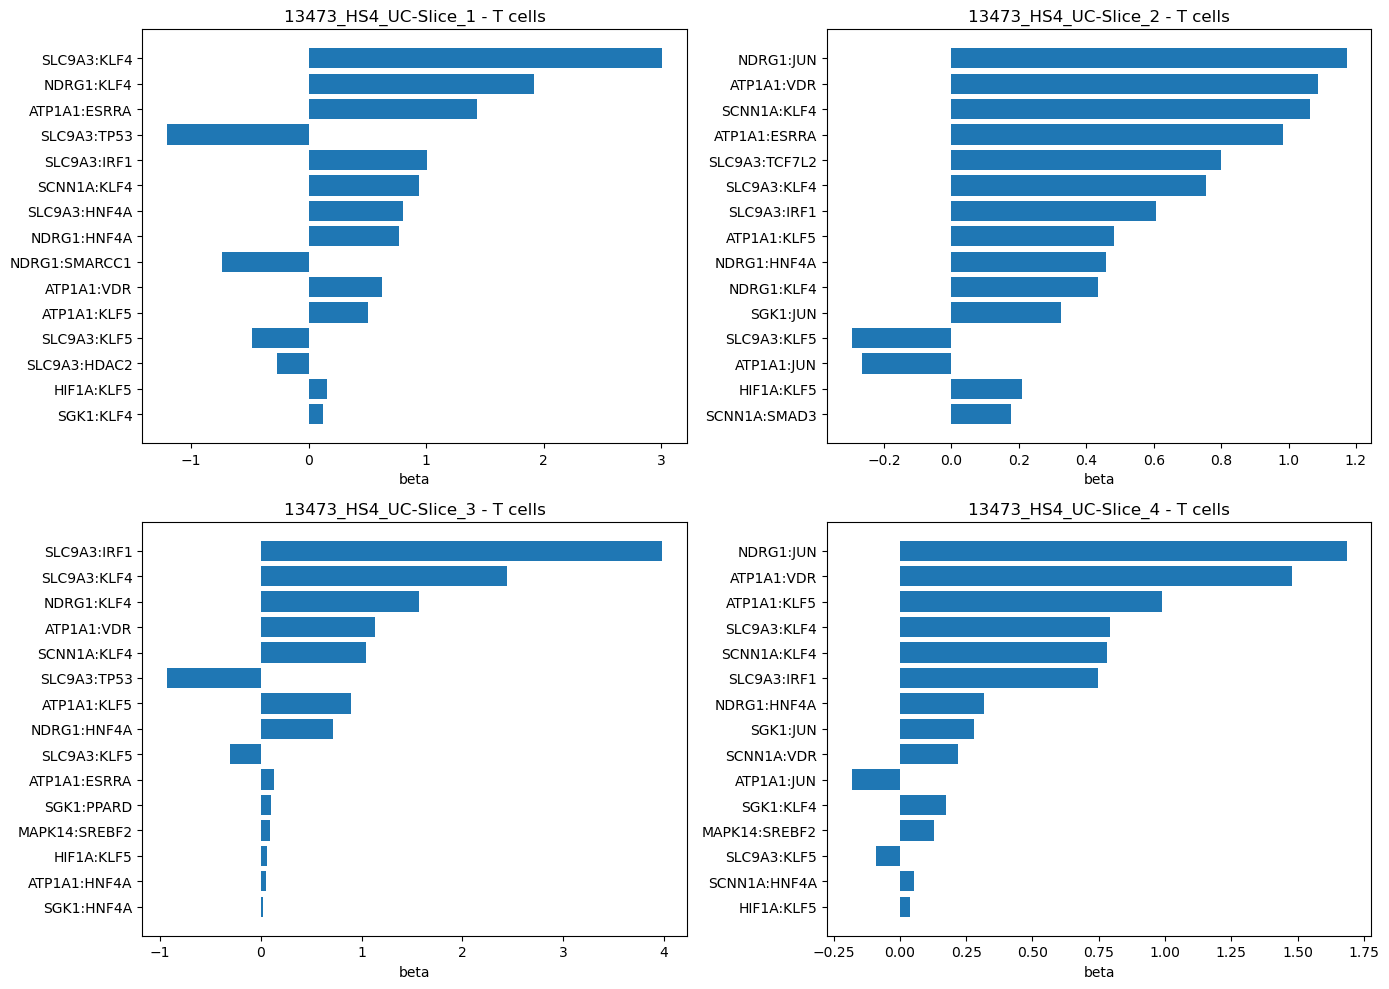

In [14]:
# Run on all samples: top T-cell coefficients per sample.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for dataset, ax in zip(samples, axes.ravel()):
    b = fit_gene_betas(load_x(dataset), annot_col=ANNOT_COL, annot_value=T_CELL, method='l1', penalty=0.001)
    plot_top_coefficients(b, top=15, ax=ax)
    ax.set_title(f'{dataset} - T cells')
fig.tight_layout()

In [ ]:
# Cell-subsampling test, glucose only: distribution of the glucose beta per sample (4 histograms).
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for dataset, ax in zip(samples, axes.ravel()):
    adx = load_x(dataset)
    gene = HIST_GENE or adx.uns['x_genes'][0]
    vals = subsample_metab_betas(adx, gene, GLUCOSE, n_subsamples=N_SUB, frac=FRAC,
                                 annot_col=ANNOT_COL, annot_value=T_CELL)
    plot_beta_histogram(vals, ax=ax, title=f'{dataset}\n{gene} ~ {GLUCOSE} (T cells)')
    ax.set_xlabel('glucose beta')
fig.tight_layout()